# Proyek Klasifikasi Gambar: Food Classification (Burger, Pizza, Sushi)
- **Nama:** Athalie Aurora
- **Email:** auroraathalie@gmail.com
- **ID Dicoding:** byrathaavle

## Import Semua Packages/Library yang Digunakan

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings("ignore")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.17.0
GPU available: False


## Data Preparation

### Data Loading

Dataset: Food Classification (Burger, Pizza, Sushi) dari Kaggle Food-101
Struktur folder: dataset/train, dataset/val, dataset/test

In [4]:
# Path konfigurasi
BASE_DIR    = os.path.dirname(os.path.abspath("__file__"))
DATASET_DIR = os.path.join(BASE_DIR, "..", "dataset")
TRAIN_DIR   = os.path.join(DATASET_DIR, "train")
VAL_DIR     = os.path.join(DATASET_DIR, "val")
TEST_DIR    = os.path.join(DATASET_DIR, "test")

CLASS_NAMES = ["burger", "pizza", "sushi"]
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32

# Hitung jumlah gambar per split
for split in ["train", "val", "test"]:
    split_dir = os.path.join(DATASET_DIR, split)
    total = 0
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        if os.path.exists(cls_dir):
            count = len([f for f in os.listdir(cls_dir)
                         if f.lower().endswith((".jpg", ".jpeg", ".png"))])
            total += count
            print(f"  {split}/{cls}: {count} gambar")
    print(f"  Total {split}: {total} gambar\n")

  train/burger: 800 gambar
  train/pizza: 800 gambar
  train/sushi: 800 gambar
  Total train: 2400 gambar

  val/burger: 100 gambar
  val/pizza: 100 gambar
  val/sushi: 100 gambar
  Total val: 300 gambar

  test/burger: 100 gambar
  test/pizza: 100 gambar
  test/sushi: 100 gambar
  Total test: 300 gambar



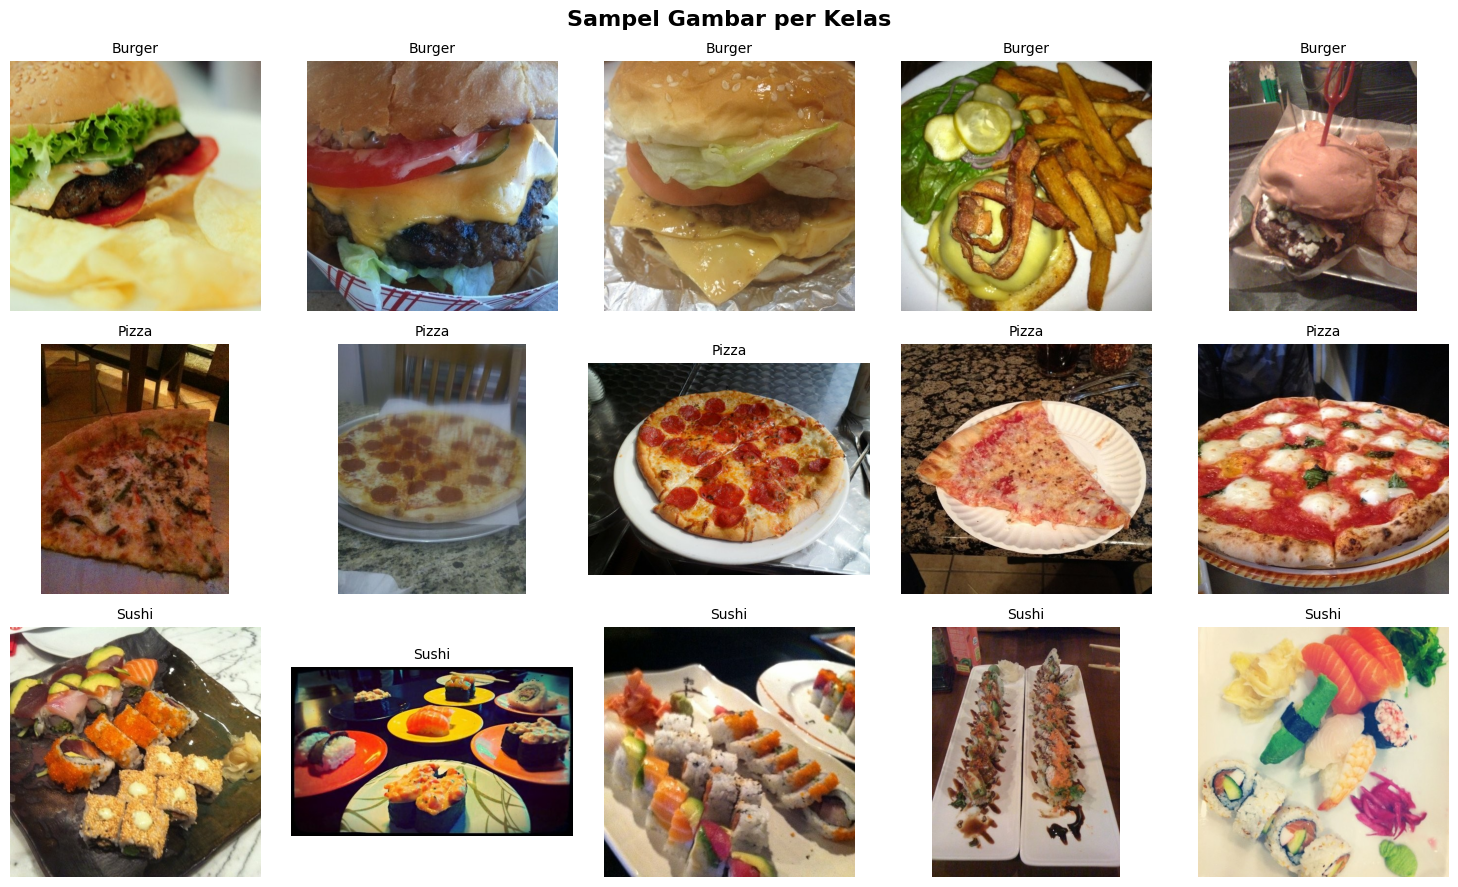

In [5]:
# Visualisasi sampel gambar dari setiap kelas
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sampel Gambar per Kelas", fontsize=16, fontweight="bold")

for row, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    images = [f for f in os.listdir(cls_dir)
              if f.lower().endswith((".jpg", ".jpeg", ".png"))][:5]
    for col, img_name in enumerate(images):
        img_path = os.path.join(cls_dir, img_name)
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].set_title(cls.capitalize(), fontsize=10)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### Data Preprocessing

#### Augmentasi & Generator

Augmentasi diterapkan hanya pada data training untuk mencegah overfitting.

In [6]:
# ImageDataGenerator

# Training: dengan augmentasi
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

# Validasi & Test: hanya rescale
val_test_datagen = ImageDataGenerator(rescale=1.0/255)

# Flow from directory
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(f"\nClass indices: {train_generator.class_indices}")
print(f"Train  : {train_generator.samples} gambar")
print(f"Val    : {val_generator.samples} gambar")
print(f"Test   : {test_generator.samples} gambar")

Found 2400 images belonging to 3 classes.
Found 300 images belonging to 3 classes.
Found 300 images belonging to 3 classes.

Class indices: {'burger': 0, 'pizza': 1, 'sushi': 2}
Train  : 2400 gambar
Val    : 300 gambar
Test   : 300 gambar


## Modelling

Arsitektur CNN Sequential dengan Conv2D + BatchNorm + MaxPooling + Dropout.

In [7]:
NUM_CLASSES = 3

model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation="relu", padding="same",
                  input_shape=(*IMG_SIZE, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 4
    layers.Conv2D(256, (3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 5
    layers.Conv2D(512, (3,3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Classifier head
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax")
], name="food_cnn")

model.summary()

Model: "food_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,967,299 (7.50 MB)

 Trainable params: 1,965,315 (7.50 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [8]:
# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Callbacks
SAVED_MODEL_DIR = os.path.join(BASE_DIR, "..", "models", "saved_model")
os.makedirs(SAVED_MODEL_DIR, exist_ok=True)

checkpoint_cb = callbacks.ModelCheckpoint(
    filepath=os.path.join(SAVED_MODEL_DIR, "best_checkpoint.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop_cb = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=7,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Model dikompilasi dan callbacks siap.")

Model dikompilasi dan callbacks siap.


In [9]:
# Training
EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb]
)

print("\nTraining selesai!")

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4266 - loss: 1.3452
Epoch 1: val_accuracy improved from None to 0.33333, saving model to d:\gitdesktop\image-classification-food-cnn\notebooks\..\models\saved_model\best_checkpoint.keras

Epoch 1: finished saving model to d:\gitdesktop\image-classification-food-cnn\notebooks\..\models\saved_model\best_checkpoint.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.4704 - loss: 1.2115 - val_accuracy: 0.3333 - val_loss: 1.4030 - learning_rate: 0.0010
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5419 - loss: 0.9972
Epoch 2: val_accuracy improved from 0.33333 to 0.33667, saving model to d:\gitdesktop\image-classification-food-cnn\notebooks\..\models\saved_model\best_checkpoint.keras

Epoch 2: finished saving model to d:\gitdesktop\image-classification-food-cnn\notebooks\..\models\saved_model\best_checkpoint.keras
75/75 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.5446 - loss: 0.9822 - val_accuracy: 0

## Evaluasi dan Visualisasi

In [10]:
# Evaluasi Test Set
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

if test_acc >= 0.90:
    print("Target aman tercapai (>= 90%)")
elif test_acc >= 0.85:
    print("Target minimal tercapai (>= 85%)")
else:
    print("Akurasi belum mencapai target. Pertimbangkan lebih banyak epoch atau fine-tuning.")

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 473ms/step - accuracy: 0.9267 - loss: 0.2220

Test Loss    : 0.2220
Test Accuracy: 0.9267 (92.67%)
Target aman tercapai (>= 90%)


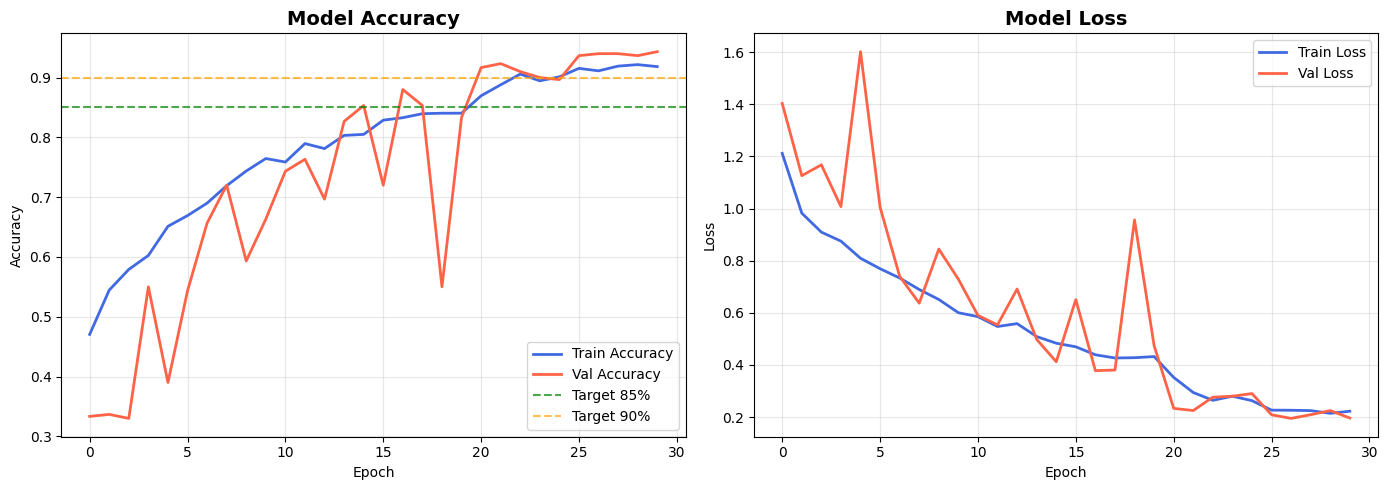

Plot disimpan ke: d:\gitdesktop\image-classification-food-cnn\notebooks\..\models\training_history.png


In [11]:
# Plot Loss & Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history["accuracy"],     label="Train Accuracy",  color="royalblue", linewidth=2)
axes[0].plot(history.history["val_accuracy"], label="Val Accuracy",    color="tomato",    linewidth=2)
axes[0].axhline(y=0.85, color="green",  linestyle="--", alpha=0.7, label="Target 85%")
axes[0].axhline(y=0.90, color="orange", linestyle="--", alpha=0.7, label="Target 90%")
axes[0].set_title("Model Accuracy", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history["loss"],     label="Train Loss",  color="royalblue", linewidth=2)
axes[1].plot(history.history["val_loss"], label="Val Loss",    color="tomato",    linewidth=2)
axes[1].set_title("Model Loss", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(BASE_DIR, "..", "models", "training_history.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot disimpan ke: {plot_path}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 300ms/step


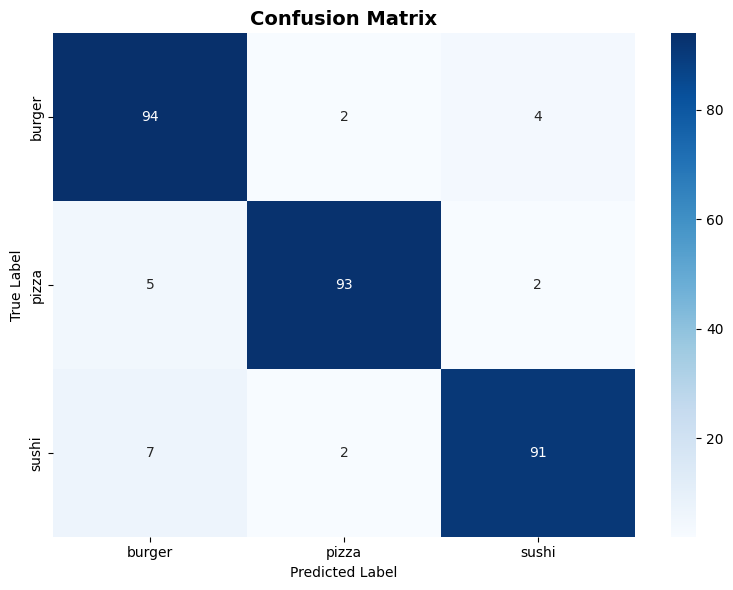


Classification Report:
              precision    recall  f1-score   support

      burger       0.89      0.94      0.91       100
       pizza       0.96      0.93      0.94       100
       sushi       0.94      0.91      0.92       100

    accuracy                           0.93       300
   macro avg       0.93      0.93      0.93       300
weighted avg       0.93      0.93      0.93       300



In [12]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

## Konversi Model

Model disimpan dalam 3 format: SavedModel, TFLite, dan TensorFlow.js

In [ ]:
# Path model
SAVED_MODEL_DIR = os.path.join(BASE_DIR, "..", "models", "saved_model")
TFLITE_DIR      = os.path.join(BASE_DIR, "..", "models", "tflite")
TFJS_DIR        = os.path.join(BASE_DIR, "..", "models", "tfjs_model")
KERAS_PATH      = os.path.join(SAVED_MODEL_DIR, "model.keras")
H5_PATH         = os.path.join(SAVED_MODEL_DIR, "model.h5")
TFLITE_PATH     = os.path.join(TFLITE_DIR, "model.tflite")

os.makedirs(SAVED_MODEL_DIR, exist_ok=True)
os.makedirs(TFLITE_DIR, exist_ok=True)
os.makedirs(TFJS_DIR, exist_ok=True)

# ── 1. Simpan .keras (Keras 3 native) ────────────────────────────────────
model.save(KERAS_PATH)
print(f"[1] .keras disimpan: {KERAS_PATH} ({os.path.getsize(KERAS_PATH)//1024} KB)")

# ── 2. Simpan .h5 via tf_keras (untuk TFJS converter) ────────────────────
import tf_keras
tf_keras_model = tf_keras.models.Sequential([
    tf_keras.layers.Conv2D(32,(3,3),activation='relu',padding='same',input_shape=(*IMG_SIZE,3)),
    tf_keras.layers.BatchNormalization(), tf_keras.layers.MaxPooling2D((2,2)),
    tf_keras.layers.Conv2D(64,(3,3),activation='relu',padding='same'),
    tf_keras.layers.BatchNormalization(), tf_keras.layers.MaxPooling2D((2,2)),
    tf_keras.layers.Conv2D(128,(3,3),activation='relu',padding='same'),
    tf_keras.layers.BatchNormalization(), tf_keras.layers.MaxPooling2D((2,2)),
    tf_keras.layers.Conv2D(256,(3,3),activation='relu',padding='same'),
    tf_keras.layers.BatchNormalization(), tf_keras.layers.MaxPooling2D((2,2)),
    tf_keras.layers.Conv2D(512,(3,3),activation='relu',padding='same'),
    tf_keras.layers.BatchNormalization(), tf_keras.layers.MaxPooling2D((2,2)),
    tf_keras.layers.GlobalAveragePooling2D(),
    tf_keras.layers.Dense(512,activation='relu'), tf_keras.layers.Dropout(0.5),
    tf_keras.layers.Dense(256,activation='relu'), tf_keras.layers.Dropout(0.3),
    tf_keras.layers.Dense(NUM_CLASSES,activation='softmax')
], name='food_cnn_h5')
tf_keras_model.set_weights(model.get_weights())
tf_keras_model.save(H5_PATH)
print(f"[2] .h5 disimpan   : {H5_PATH} ({os.path.getsize(H5_PATH)//1024} KB)")

# ── 3. TFLite via concrete function ──────────────────────────────────────
run_model = tf.function(lambda x: model(x))
concrete_func = run_model.get_concrete_function(
    tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype)
)
converter = tf.lite.TFLiteConverter.from_concrete_functions([concrete_func], model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()
with open(TFLITE_PATH, 'wb') as f:
    f.write(tflite_bytes)
print(f"[3] .tflite disimpan: {TFLITE_PATH} ({os.path.getsize(TFLITE_PATH)//1024} KB)")

In [ ]:
# ── 4. TensorFlow.js dari .h5 ───────────────────────────────────────────
import subprocess, sys

venv_dir = os.path.dirname(sys.executable)
converter_exe = os.path.join(venv_dir, 'tensorflowjs_converter')

result = subprocess.run(
    [converter_exe,
     '--input_format=keras',
     '--output_format=tfjs_graph_model',
     H5_PATH, TFJS_DIR],
    capture_output=True, text=True
)

if result.returncode == 0:
    files = os.listdir(TFJS_DIR)
    print(f"[4] TFJS disimpan: {TFJS_DIR}")
    for f in files:
        fsize = os.path.getsize(os.path.join(TFJS_DIR, f))
        print(f"    {f}: {fsize//1024} KB")
else:
    print('Error TFJS:', result.stderr[-300:])

print('\nSemua model tersimpan!')

## Inference (Optional)

Uji model dengan gambar baru menggunakan SavedModel dan TFLite.

Inferensi pada sampel gambar dari test set:

[burger] -> Prediksi: burger | Confidence: 99.93%
   burger  : 99.93%
   pizza   : 0.01%
   sushi   : 0.06%

[pizza] -> Prediksi: pizza | Confidence: 99.96%
   burger  : 0.01%
   pizza   : 99.96%
   sushi   : 0.03%

[sushi] -> Prediksi: sushi | Confidence: 99.96%
   burger  : 0.00%
   pizza   : 0.04%
   sushi   : 99.96%



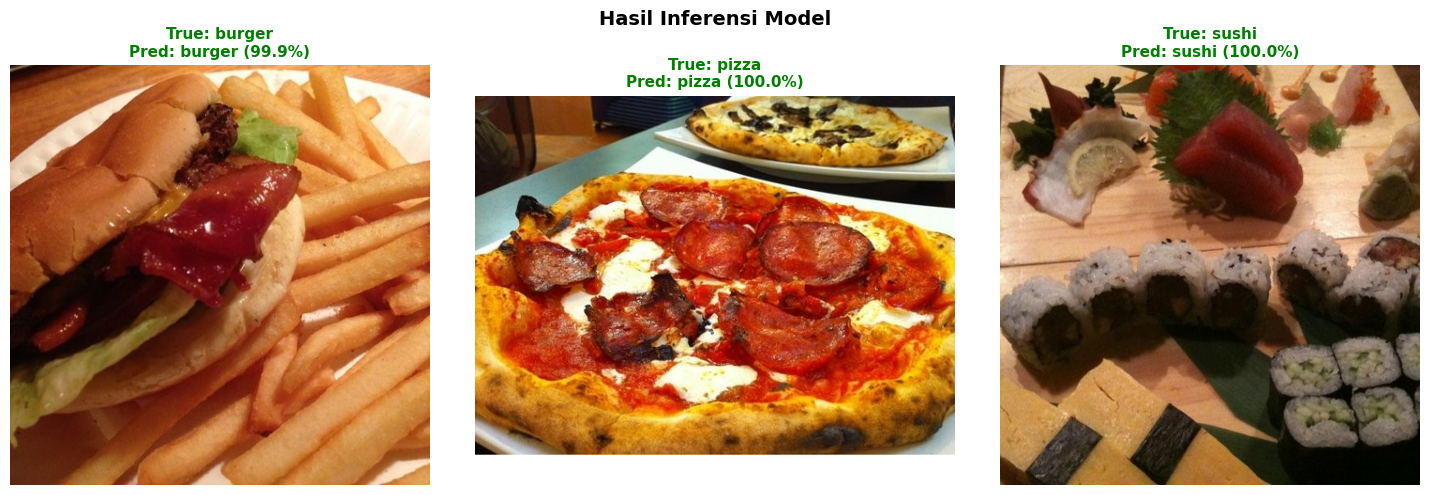

In [17]:
# Fungsi Inferensi
def preprocess_image(image_path, img_size=(224, 224)):
    """Load dan preprocess gambar untuk inferensi."""
    img = tf.keras.utils.load_img(image_path, target_size=img_size)
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    return np.expand_dims(img_array, axis=0)

def predict_image(image_path, use_tflite=False):
    """Prediksi kelas gambar."""
    img_array = preprocess_image(image_path)

    if use_tflite:
        interpreter = tf.lite.Interpreter(model_path=tflite_path)
        interpreter.allocate_tensors()
        input_details  = interpreter.get_input_details()
        output_details = interpreter.get_output_details()
        interpreter.set_tensor(input_details[0]["index"], img_array.astype(np.float32))
        interpreter.invoke()
        preds = interpreter.get_tensor(output_details[0]["index"])[0]
    else:
        preds = model.predict(img_array, verbose=0)[0]

    predicted_idx   = np.argmax(preds)
    predicted_class = CLASS_NAMES[predicted_idx]
    confidence      = preds[predicted_idx]
    return predicted_class, confidence, preds

# Uji inferensi pada gambar dari test set
print("Inferensi pada sampel gambar dari test set:\n")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Hasil Inferensi Model", fontsize=14, fontweight="bold")

for i, cls in enumerate(CLASS_NAMES):
    cls_test_dir = os.path.join(TEST_DIR, cls)
    test_images  = [f for f in os.listdir(cls_test_dir)
                    if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not test_images:
        continue
    sample_path = os.path.join(cls_test_dir, test_images[0])
    pred_class, confidence, probs = predict_image(sample_path)

    img = mpimg.imread(sample_path)
    axes[i].imshow(img)
    color = "green" if pred_class == cls else "red"
    axes[i].set_title(
        f"True: {cls}\nPred: {pred_class} ({confidence*100:.1f}%)",
        color=color, fontsize=11, fontweight="bold"
    )
    axes[i].axis("off")
    print(f"[{cls}] -> Prediksi: {pred_class} | Confidence: {confidence*100:.2f}%")
    for c, p in zip(CLASS_NAMES, probs):
        print(f"   {c:<8}: {p*100:.2f}%")
    print()

plt.tight_layout()
plt.show()